В файле **WIPO-GII_2022.xlsx** содержаться данные по странам о показателях, используемых для расчета Global Innovation Index за 2022 год.

### В файле следующие переменные:
- Country
- Business environment
- Business sophistication index
- Citable documents H-index
- Creative goods and services
- Creative goods exports, % total trade
- Creative outputs index
- Cultural and creative services exports, % total trade
- Domestic market scale, bn PPP
- Ecological sustainability
- Expenditure on education, % GDP
- Firms offering formal training, %
- General infrastructure
- Government effectiveness
- Government's online service
- Graduates in science and engineering, %
- Gross expenditure on R&D, % GDP
- High-tech exports, % total trade
- High-tech imports, % total trade
- High-tech manufacturing, %
- Human capital and research index
- Information and Communications Technology access
- Information and Communications Technology services exports, % total trade
- Information and Communications Technology services imports, % total trade
- Information and Communications Technology use
- Infrastructure index
- Intangible assets
- Joint venture/strategic alliance deals/bn PPP GDP
- Knowledge absorption
- Knowledge and technology outputs index
- Knowledge workers
- Knowledge-intensive employment, %
- Logistics performance
- Market sophistication index
- Mobile app creation/bn PPP GDP
- Online creativity
- PISA scales in reading, maths and science
- Political and operational stability
- Political environment
- Pupil-teacher ratio, secondary
- QS university ranking average score of top 3 universities
- Research and development (R&D)
- Scientific and technical articles/bn PPP GDP
- Software spending, % GDP
- Tertiary education
- Tertiary enrolment, % gross
- University-industry R&D collaboration
- Region
- Region2
- Euro area
- European Union
- OECD members
- Least developed countries
- Income
- High income

Выполните, пожалуйста, задания.

In [219]:
import pandas as pd
%matplotlib inline
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings("ignore")

#1. Выберите не менее 5 интересующих Вас метрических переменных для последующего проведения кластерного анализа данных. Приведите аргументы в пользу возможности их использования для кластеризации.

In [220]:
df = pd.read_excel('WIPO-GII_2022.xlsx')
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 139 entries, 0 to 138
Data columns (total 55 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Country                                                                         139 non-null    object 
 1   Business environment_2022                                                       132 non-null    float64
 2   Business sophistication index_2022                                              132 non-null    float64
 3   Citable documents H-index_2022                                                  132 non-null    float64
 4   Creative goods and services_2022                                                132 non-null    float64
 5   Creative goods exports, % total trade_2022                                      132 non-null    float64
 6   Creative outputs i

##1.1 Очистим от выбросов:

In [221]:
df[df['Graduates in science and engineering, %_2022'].isnull()]
#проверка, с какими объектами проблемы

,Country,Business environment_2022,Business sophistication index_2022,Citable documents H-index_2022,Creative goods and services_2022,"Creative goods exports, % total trade_2022",Creative outputs index_2022,"Cultural and creative services exports, % total trade_2022","Domestic market scale, bn PPP$_2022",Ecological sustainability_2022,...,"Tertiary enrolment, % gross_2022",University-industry R&D collaboration_2022,Region,Region2,Euro area,European Union,OECD members,Least developed countries,Income,High income
8,Puerto Rico,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Latin America & Caribbean,Americas,0,0,0,0,high income,1
18,Cabo Verde,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Sub-Saharan Africa,Sub-Saharan Africa,0,0,0,0,middle income,0
25,Malawi,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Sub-Saharan Africa,Sub-Saharan Africa,0,0,0,1,low income,0
35,Sierra Leone,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Sub-Saharan Africa,Sub-Saharan Africa,0,0,0,1,low income,0
48,Lebanon,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Middle East & North Africa,Middle East and North Africa,0,0,0,0,middle income,0
112,Solomon Islands,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,East Asia & Pacific,Asia-Pacific,0,0,0,1,middle income,0
119,Bolivia,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,Latin America & Caribbean,Americas,0,0,0,0,middle income,0


In [222]:
df = df[df['Graduates in science and engineering, %_2022'].notnull()].reset_index(drop=True)

##1.2 Анализируем признаки

In [223]:
df['Domestic market scale, bn PPP$_2022'].describe()

,"Domestic market scale, bn PPP$_2022"
count,132.000000
mean,15.701515
std,25.360663
min,0.000000
25%,1.175000
50%,4.450000
75%,15.225000
max,100.000000


In [224]:
df['Expenditure on education, % GDP_2022'].describe()

,"Expenditure on education, % GDP_2022"
count,132.000000
mean,36.607576
std,18.977913
min,0.000000
25%,24.175000
50%,35.300000
75%,47.325000
max,100.000000


In [225]:
df['High-tech manufacturing, %_2022'].describe()

,"High-tech manufacturing, %_2022"
count,132.000000
mean,28.535606
std,25.190920
min,0.000000
25%,4.700000
50%,22.750000
75%,48.600000
max,100.000000


In [226]:
df['Creative goods and services_2022'].describe()

,Creative goods and services_2022
count,132.000000
mean,17.721970
std,13.593338
min,0.000000
25%,5.450000
50%,14.550000
75%,28.500000
max,52.700000


In [227]:
df['Ecological sustainability_2022'].describe()

,Ecological sustainability_2022
count,132.000000
mean,29.426515
std,12.301250
min,13.000000
25%,19.050000
50%,25.550000
75%,38.200000
max,57.300000


##ПОЧЕМУ ЭТИ ПРИЗНАКИ?
При выборе признаков, я основовался на идее о том, что признаки должны описывать страну с разных сторон(творчество, образование, технологии, объем рынка и т д), чтобы разделение на кластеры стран было более содержательным.
Все признаки являются метрическими, что подходит для кластерного анализа.

In [228]:
features = ['Domestic market scale, bn PPP$_2022','Expenditure on education, % GDP_2022',
                                    'High-tech manufacturing, %_2022', 'Creative goods and services_2022',
                                    'Ecological sustainability_2022']
scaler = StandardScaler()
X = scaler.fit_transform(df[features])



## ЧТО ЖДЕМ ОТ КЛАСТЕРИЗАЦИИ?
Выбранные признаки описывают развитие сторон с разных сторон. Выдвинем такую гипотезу, страны первого, второго и третьего мира обычно отличаются друг от друга со всех сторон(и культурно, и экономически, и технологически и т д)

#2. Выберите подходящий алгоритм кластеризации и обоснуйте свой выбор. Определите число кластеров, объясните своё решение. Опишите получившиеся кластеры с помощью описательной статистки. Нужно не просто рассчитать статистики в таблицах, но детально описать полученные результаты. Дайте названия кластерам и обоснуйте их.

##2.1 Попробуем использовать алгоритм k-means, признаки метрические, посмотрим, что получится

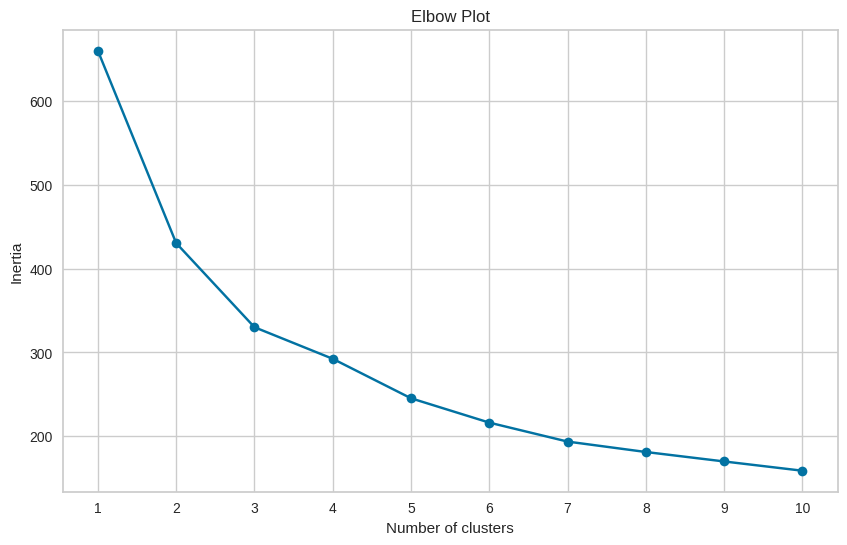

In [229]:
inertia = []
k_range = range(1, 11)
for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=1)
    kmeans.fit(X)
    inertia.append(kmeans.inertia_)
plt.figure(figsize=(10, 6))
plt.plot(k_range, inertia, marker='o')
plt.title('Elbow Plot')
plt.xlabel('Number of clusters')
plt.ylabel('Inertia')
plt.xticks(k_range)
plt.show()

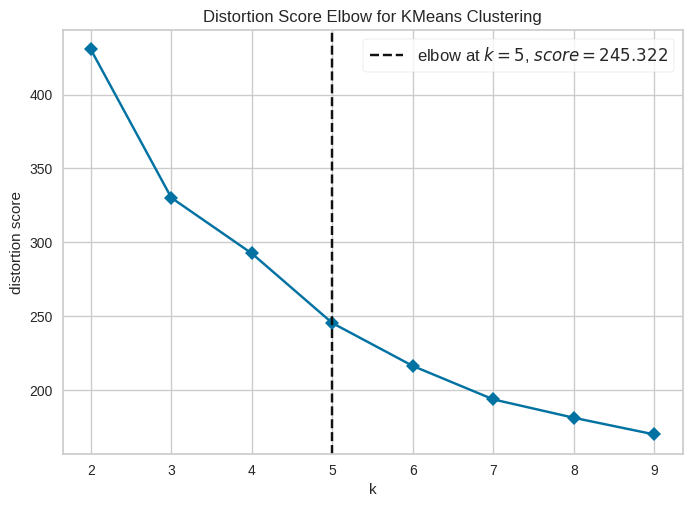

In [230]:
from yellowbrick.cluster import KElbowVisualizer

model = KMeans(random_state=1)
visualizer = KElbowVisualizer(model, k=(2,10), timings=False)

visualizer.fit(X)
visualizer.show()
plt.show()

k=5 - оптимальный выбор

In [231]:
kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
labels = kmeans.fit_predict(X)
df['Cluster'] = labels
df['Cluster'].value_counts()

,count
Cluster,
2,40
0,33
1,25
4,19
3,15


In [232]:
cluster_summary = df.groupby('Cluster')[features].mean().round(2)
print(cluster_summary)

         Domestic market scale, bn PPP$_2022  \
Cluster                                        
0                                       6.16   
1                                      14.66   
2                                       6.00   
3                                      79.46   
4                                       3.73   

         Expenditure on education, % GDP_2022  \
Cluster                                         
0                                       55.62   
1                                       43.05   
2                                       21.06   
3                                       38.35   
4                                       26.47   

         High-tech manufacturing, %_2022  Creative goods and services_2022  \
Cluster                                                                      
0                                  18.18                              9.66   
1                                  60.52                             30.65   
2      

##2.2 Анализ полученных результатов

Получили достаточно сбалансированные по размеру кластеры, попробуем описать каждого из них.

0. "Вечный ученик" - высокие расходы на образование, но маленький внутренний рынок, слабое развитие технологичного производства

1. "Культурный и технологичный" - высокое производство культурных благ, высокое развитие технологического производства

2. "Не киноман" - противополжность предыдущему пункту, так же имеет плохую экологическую ситуацию

3. "Сын маминой подруги" - большой внутренний рынок, высокое технологическое производство, остальные пункты не ниже среднего

4. "Зато я люблю природу" - очень низкие показатели по всем пунктам, кроме экологической ситуации

## 2.3 Попробуем использовать другие алгоритмы и сравним полученные результаты

### 2.3.1 DBSCAN

In [233]:
dbscan = DBSCAN(eps=0.7, min_samples=4)
labels_db = dbscan.fit_predict(X)
df['Cluster_dbscan'] = labels_db
df['Cluster_dbscan'].value_counts()

,count
Cluster_dbscan,
-1,83
0,49


In [234]:
dbscan = DBSCAN(eps=1.2, min_samples=4)
labels_db = dbscan.fit_predict(X)
df['Cluster_dbscan'] = labels_db
df['Cluster_dbscan'].value_counts()

,count
Cluster_dbscan,
0,105
-1,27


In [235]:
dbscan = DBSCAN(eps=1, min_samples=4)
labels_db = dbscan.fit_predict(X)
df['Cluster_dbscan'] = labels_db
df['Cluster_dbscan'].value_counts()

,count
Cluster_dbscan,
0,68
-1,41
1,12
2,11


In [236]:
cluster_summary = df.groupby('Cluster_dbscan')[features].mean().round(2)
print(cluster_summary)

                Domestic market scale, bn PPP$_2022  \
Cluster_dbscan                                        
-1                                            34.90   
 0                                             7.04   
 1                                             9.98   
 2                                             3.92   

                Expenditure on education, % GDP_2022  \
Cluster_dbscan                                         
-1                                             40.54   
 0                                             34.00   
 1                                             44.68   
 2                                             29.26   

                High-tech manufacturing, %_2022  \
Cluster_dbscan                                    
-1                                        41.17   
 0                                        15.43   
 1                                        66.62   
 2                                        20.93   

                Creative 

Получилось плохое разделение, при выборе большого епсилон, алгоритм все относит к одному кластеру, при выборе маленького, относит слишком много данных к шумовым

### 2.3.2 Иерархическая кластеризация:

In [237]:
from sklearn.cluster import AgglomerativeClustering

agg = AgglomerativeClustering(n_clusters=3, linkage='ward')
labels_agg = agg.fit_predict(X_scaled)
df['Cluster_hier'] = labels_agg
df['Cluster_hier'].value_counts()

,count
Cluster_hier,
0,71
1,48
2,13


In [238]:
cluster_summary = df.groupby('Cluster_hier')[features].mean().round(2)
print(cluster_summary)

              Domestic market scale, bn PPP$_2022  \
Cluster_hier                                        
0                                            5.59   
1                                           12.52   
2                                           82.65   

              Expenditure on education, % GDP_2022  \
Cluster_hier                                         
0                                            36.37   
1                                            36.68   
2                                            37.64   

              High-tech manufacturing, %_2022  \
Cluster_hier                                    
0                                       13.28   
1                                       44.14   
2                                       54.24   

              Creative goods and services_2022  Ecological sustainability_2022  
Cluster_hier                                                                    
0                                         8.34         

В целом, неплохо

0 - неразвитые страные, страны 3-го мира

In [239]:
df[df['Cluster_hier'] == 0]['Country'].head()

,Country
0,Cote d'Ivoire
2,"Egypt, Arab Rep."
4,"Iran, Islamic Rep."
6,Lao PDR
7,Myanmar


1 - в целом, культурно обогащенные, технологичные страны, но с небольшим внутренним рынком, страны 2-го мира

In [240]:
df[df['Cluster_hier'] == 1]['Country'].head()

,Country
1,Czechia
3,"Hong Kong SAR, China"
5,"Korea, Rep."
9,Slovak Republic
11,"Yemen, Rep."


2 - страны 1-го мира

In [241]:
df[df['Cluster_hier'] == 2]['Country'].head()

,Country
8,Russian Federation
10,Turkiye
63,France
65,Germany
70,Italy


## 2.4 Итоговый выбор кластеризации

Разделение иерархической кластеризации получилось более осмысленным, по сравнению с остальными, поэтому будем использовать ее, также отметим, что наша выдвинутая гипотеза подтвердилась, добавим тогда признак, к какому "миру" относится страна, к 1-му, 2-му или 3-му


In [242]:
mapping = {0: 3, 1: 2, 2: 1}
df["Num_world"] = df["Cluster_hier"].map(mapping)


#3. Проведите апостериорный анализ данных на основе категориальных переменных датасета. Например, рассмотрите как распределены страны разных регионов по кластерам или в какие кластеры в основном попали страны-члены ОЭСР?

In [243]:
df.groupby('Region2')['Num_world'].value_counts(sort=False)

Region2                       Num_world
Americas                      1             2
                              2             4
                              3            14
Asia-Pacific                  1             4
                              2            10
                              3            12
Europe                        1             7
                              2            32
                              3             6
Middle East and North Africa  2             2
                              3            12
Sub-Saharan Africa            3            27
Name: count, dtype: int64

Все абсолютно логично, в Европе много стран 1-го мира, в "бедных" регионах(в Африке, средней Азии) много стран 2-го и 3-го мира

In [244]:
df.groupby('Num_world')['OECD members'].value_counts(sort=False)

Num_world  OECD members
1          0                5
           1                8
2          0               21
           1               27
3          0               68
           1                3
Name: count, dtype: int64

Много стран OECD среди стран 1-го и 2-го мира, что логично

In [245]:
df.groupby('Num_world')['Least developed countries'].value_counts(sort=False)

Num_world  Least developed countries
1          0                            13
2          0                            47
           1                             1
3          0                            49
           1                            22
Name: count, dtype: int64

Нет неразвитых стран среди стран 1-го мира, и всего лишь одна страна среди стран 2-го мира, что логично

In [246]:
df.groupby('European Union')['Num_world'].value_counts(sort=False)

European Union  Num_world
0               1             9
                2            25
                3            71
1               1             4
                2            23
Name: count, dtype: int64

Среди стран евросоюза нет стран 3-го мира, что логично

## ВЫВОД

 В общем, получлось все правильно, можем сделать вывод, что кластеризация прошла довольно успешно

#4. Почему получилась именно такая кластерная структура? Полученные результаты соответствуют вашем изначальным предположениям или оказались неожиданными?

Да, все получилось замечательно, кластеризация получилась успешной, кластерная структура имеет разделение стран на страны 1-го, 2-го и 3-го мира. Наша изначальная гипотеза подтвердилась.

#5. ДОПОЛНИТЕЛЬНАЯ РАБОТА

Попробуем поработать с категориальной кластеризацией, хоть признаки в данном датасете, не очень для этого подходят


In [247]:
pip install kmodes

In [248]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 132 entries, 0 to 131
Data columns (total 59 columns):
 #   Column                                                                          Non-Null Count  Dtype  
---  ------                                                                          --------------  -----  
 0   Country                                                                         132 non-null    object 
 1   Business environment_2022                                                       132 non-null    float64
 2   Business sophistication index_2022                                              132 non-null    float64
 3   Citable documents H-index_2022                                                  132 non-null    float64
 4   Creative goods and services_2022                                                132 non-null    float64
 5   Creative goods exports, % total trade_2022                                      132 non-null    float64
 6   Creative outputs i

In [249]:
from kmodes.kmodes import KModes

cat_features = ['Region', 'OECD members', 'Least developed countries', 'European Union', 'Income']

df_cat = df[cat_features].astype(str)

km = KModes(n_clusters=3, init='Huang', n_init=5, random_state=42)
labels = km.fit_predict(df_cat)

df['Cluster_kmodes'] = labels
df['Cluster_kmodes'].value_counts()

,count
Cluster_kmodes,
1,76
0,38
2,18


In [250]:
df[df['Cluster_kmodes'] == 0]['Country'].head()

,Country
1,Czechia
5,"Korea, Rep."
9,Slovak Republic
41,Israel
52,Austria


In [251]:
df[df['Cluster_kmodes'] == 1]['Country'].head()

,Country
0,Cote d'Ivoire
2,"Egypt, Arab Rep."
3,"Hong Kong SAR, China"
4,"Iran, Islamic Rep."
6,Lao PDR


In [252]:
df[df['Cluster_kmodes'] == 2]['Country'].head()

,Country
11,"Yemen, Rep."
12,Angola
13,Benin
15,Burkina Faso
16,Burundi


In [253]:
df.groupby('Region2')['Cluster_kmodes'].value_counts(sort=False)

Region2                       Cluster_kmodes
Americas                      0                  3
                              1                 17
Asia-Pacific                  0                  4
                              1                 22
Europe                        0                 30
                              1                 14
                              2                  1
Middle East and North Africa  0                  1
                              1                 13
Sub-Saharan Africa            1                 10
                              2                 17
Name: count, dtype: int64

Ну в целом, неплохо, тут, как бы, 2 - очень бедные страны, 1 - что-то среднее между странами 2-го и 3-го мира, а 0 - развитые страны. Можно сказать, что кластеризация прошла успешно, но результаты менее удобные и наглядные, по сравнению с иерархической кластеризацией

### Комментарии к заданию и принципам его оценивания:

 - Все пункты задания должны сопровождаться _выполненным_ фрагментом кода.
 - Если Вы получили результаты в виде статистических показателей, таблиц или графиков, при этом никак их не прокомментировали и не сформулировали содержательные выводы на их основе, то работа оценивается в 0 баллов, в этом случае анализ данных не проведён.
 - Если Вы полностью выполнили это задание, то получаете за него 8 баллов (отлично). Для получения более высокой оценки нужно выйти за рамки предложенного задания. В случае с текущим заданием это может быть дополнительное самостоятельное изучение других алгоритмов кластеризации и их применение для анализа данных, или развернутое и глубокое исследование имеющихся данных на основе применения всех пройденных на занятиях алгоритмов кластеризации, сравнение результатов и выбор лучшей кластерной модели с объяснением своего выбора.
 - В этом задании четыре пункта. Первый весит 10%, второй - 50%, третий - 30%, четвертый - 10%.
 - Задание можно выполнять индивидуально или в группе из 2 человек, критерии оценивания при этом не меняются.
 - Если задание выполняется вдвоем, то в Smart LMS работу загружает только один из студентов.
 - В названии загружаемого в Smart LMS файла нужно указать фамилию(ии) автора(ов) работы.

### Этот файл нужно сохранить как Jupyter Notebook (.ipynb) и загрузить в Smart LMS до 23:55 28 октября.

- При сдаче работы до 23:55 29 октября вычитается 1 балл из итоговой оценки.
- При сдаче работы до 23:55 30 октября вычитаются 2 балла из итоговой оценки.
- После **23:55 30 октября** работа не принимается.